<h4>Импорт библиотек</h4>

In [2]:
import numpy
import pandas as pd
import seaborn as sns
import numpy as np
# import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import kruskal, mannwhitneyu, ttest_ind, f_oneway, pearsonr, spearmanr, shapiro
import matplotlib.pyplot as plt
import warnings
from itertools import combinations

warnings.filterwarnings('ignore')

<h4>Инициализация функций для предобработки</h4>

In [3]:
def check_normal(values: pd.Series, alp: float) -> bool:
    return shapiro(values).pvalue > alp

In [4]:
def replace_mistakes(data: pd.DataFrame) -> pd.DataFrame:
    data["region"] = data["region"].replace("Unjted States", "United States")
    data["region"] = data["region"].replace("Frаnce", "France")  # it's NOT the same
    data["region"] = data["region"].replace("Frаncе", "France")  # it's NOT the same
    data["region"] = data["region"].replace("Franсe", "France")  # it's NOT the same

    data["region"] = data["region"].replace("germany", "Germany")
    data["region"] = data["region"].replace("UК", "UK")  # it's NOT the same

    data["channel"] = data["channel"].replace("контексная реклама", "контекстная реклама")
    data["device"] = data["device"].replace("Android", "android")  # idk what name we will use? but i like this
    # maybe there are other mistakes in columns
    # maybe we can use list with for
    # we have 0.86271506 value in promo_code? but it needs to be 0 or 1
    data["promo_code"] = data["promo_code"].replace(0.86271506, 1)

    # print(data["promo_code"].unique())
    return data

In [5]:
def time_of_day(hours: int) -> str:
    if 360 <= (hours * 60) <= 599:  # 06:00 - 09:59
        return "Утро"
    elif 600 <= (hours * 60) <= 1019:  # 10:00 - 16:59
        return "День"
    elif 1020 <= (hours * 60) <= 1319:  # 17:00 - 21:59
        return "Вечер"
    else:
        return "Ночь"


def to_time_columns(data: pd.DataFrame) -> pd.DataFrame:
    data['session_date'] = pd.to_datetime(data['session_date'], format='%Y-%m-%d')  # Приведение к правильному формату
    data['session_start'] = pd.to_datetime(data['session_start'], format='%Y-%m-%d %H:%M:%S')
    data['session_end'] = pd.to_datetime(data['session_end'], format='%Y-%m-%d %H:%M:%S')
    data["time_of_day"] = data["hour_of_day"].apply(time_of_day)
    return data

In [6]:
def fill_all_errors(data: pd.DataFrame) -> pd.DataFrame:
    data = fill_errors(data, "sessiondurationsec", "median", fill_only="up")
    data = fill_errors(data, "revenue", "median")
    return data


def fill_missing_with_dup(data: pd.DataFrame, rows: pd.Series, column: str) -> pd.DataFrame:
    data.loc[rows, column] = data.loc[rows, column].fillna(method="ffill").fillna(method="bfill")
    return data


def fill_missing_data_categorical(data: pd.DataFrame) -> pd.DataFrame:
    user_ids = data["user_id"].unique()
    for user_id in user_ids:
        if len(data[data["user_id"] == user_id]) == 1:
            continue
        rows = data["user_id"].map(lambda x: x == user_id)
        data = fill_missing_with_dup(data, rows, "region")
        data = fill_missing_with_dup(data, rows, "device")
        data = fill_missing_with_dup(data, rows, "channel")
    return data

In [7]:
def plot_corr_with_nans(data: pd.DataFrame, x: str, y: str, payer: str | None = "yes") -> None:
    if payer:
        data = data[data["payer"] == payer]
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
    sns.boxplot(data.dropna(), x=x, y=y, ax=ax1)
    sns.boxplot(fill_na(data.copy(), x, "mode"), x=x, y=y, ax=ax2)
    sns.boxplot(data.fillna({x: "other"}), x=x, y=y, ax=ax3)

In [8]:
def fill_na(data: pd.DataFrame | pd.Series, column: str, method: str, group: list[str] = None):
    """
    :param data: pd.DataFrame
    :param column: name of the column to fill
    :param method: ["drop", "median", "back", "mean", "mode", "interpolate"]
    :param group: list of column names
    :return: modified data
    """
    match method:
        case "median":
            if group:
                data[column].fillna(data.groupby(group)[column].transform(method), inplace=True)
            else:
                data[column] = data[column].fillna(data[column].median())
        case "mean":
            if group:
                data[column].fillna(data.groupby(group)[column].transform(method), inplace=True)
            else:
                data[column].fillna(data[column].mean(), inplace=True)
        case "mode":
            if group:
                data[column].fillna(data.groupby(group)[column].transform(lambda x: x.mode().values[0]), inplace=True)
            else:
                data[column] = data[column].fillna(data[column].mode().values[0])
        case "back":
            data[column] = data[column].bfill()
        case "interpolate":
            data[column] = data[column].interpolate()
        case "drop":
            data[column].dropna(inplace=True)
        case _:
            raise ValueError(f"method {method} not found")
    return data


def fill_errors(df: pd.DataFrame, columns: str | list[str], fill_with: str, err_range: float = 3,
                fill_only: str = "both") -> pd.DataFrame:
    """
    :param df: pd.DataFrame
    :param columns: list of column names
    :param fill_with: ["drop", "median", "mean", "mode"]
    :param err_range: 3 for strong mistakes, 1.5 for usual mistakes
    :param fill_only: ["both", "up", "down"]
    :return: modified data
    """
    if isinstance(columns, str):
        columns = [columns]
    for col in columns:
        err_max = df[col].quantile(0.75) + err_range * (df[col].quantile(0.75) - df[col].quantile(0.25))
        err_min = df[col].quantile(0.25) - err_range * (df[col].quantile(0.75) - df[col].quantile(0.25))
        match fill_with:
            case "median":
                med = df[err_max > df[col]][df[col] > err_min][col].median()
            case "mean":
                med = df[err_max > df[col]][df[col] > err_min][col].mean()
            case "mode":
                med = df[err_max > df[col]][df[col] > err_min][col].mode()[0]
            case "drop":
                df[col] = df[err_max > df[col]][df[col] > err_min][col]
                continue
            case _:
                raise ValueError(f"unable to fill column {col} with {fill_with}")
        df[col] = df[col].map(lambda x: med if x >= err_max and fill_only in ["both", "up"]
                                               or x <= err_min and fill_only in ["both", "down"] else x)
    return df


<h4>Загрузка данных и предобработка</h4>

In [9]:
df = pd.read_csv("./data/data.csv", encoding="utf-8", sep=",")
df.columns = df.columns.str.lower().str.replace(" ", "_")
df = replace_mistakes(df)
df = to_time_columns(df)
df = fill_all_errors(df)
df["promo_code"] = df["promo_code"].fillna(0)
df["revenue"] = df["revenue"].fillna(0)
df["payer"] = df["revenue"].map(lambda x: "yes" if x != 0 else "no")
df["sum"] = df["revenue"] * (1 - df["promo_code"] / 10)
df = df.drop_duplicates(subset=["user_id", "session_start", "session_end"])
df = fill_missing_data_categorical(df)
for col in ['region', 'device', 'channel']:
    df = fill_na(df, column=col, method='mode')
display(df.head())

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,time_of_day,payer,sum
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.0,2019-05-01,5,3,0,2019-05-01 00:06:40,4999.0,Mobile payments,0.0,Ночь,yes,4999.0
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.0,2019-05-01,5,3,7,NaN,0.0,NaN,0.0,Утро,no,0.0
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.0,2019-05-01,5,3,4,NaN,0.0,NaN,0.0,Ночь,no,0.0
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.0,2019-05-01,5,3,18,NaN,0.0,NaN,0.0,Вечер,no,0.0
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.0,2019-05-02,5,4,14,NaN,0.0,NaN,0.0,День,no,0.0


<h4>Таблица для проверки пропусков, пользователи из которых уже посещали сайт</h4>

In [10]:
new_df_dub = df[df["user_id"].isin(df["user_id"][df["user_id"].duplicated()])].sort_values("user_id")
display(new_df_dub.head())

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,time_of_day,payer,sum
564,61219447121,UK,PC,контекстная реклама,2019-08-18 08:16:27,2019-08-18 08:28:59,752.0,2019-08-18,8,7,8,2019-08-18 08:16:33,4999.0,Cash,0.0,Утро,yes,4999.0
408,61219447121,UK,PC,контекстная реклама,2019-07-23 03:37:05,2019-07-23 03:43:28,383.0,2019-07-23,7,2,3,2019-07-23 03:37:11,4999.0,Cash,0.0,Ночь,yes,4999.0
286,87458247642,UK,Mac,контекстная реклама,2019-06-28 16:55:35,2019-06-28 17:22:30,1615.0,2019-06-28,6,5,17,2019-06-28 16:55:52,4999.0,E-wallet,0.0,Вечер,yes,4999.0
547,87458247642,UK,Mac,контекстная реклама,2019-08-16 17:33:09,2019-08-16 18:02:53,1784.0,2019-08-16,8,5,18,2019-08-16 17:33:25,4999.0,Credit card,0.0,Вечер,yes,4999.0
333,213468351687,United States,Mac,социальные сети,2019-07-05 11:58:53,2019-07-05 12:30:36,1903.0,2019-07-05,7,5,12,NaN,0.0,NaN,0.0,День,no,0.0


<h4>Инициализация функций для расчетов и графического анализа</h4>

In [11]:
def calculate_normal_time(sec: int) -> str:
    m, s = sec // 60, sec % 60
    # h, m = m // 60, m % 60
    # d, h = h // 24, h % 24
    return f"Минут: {m}\nСекунд: {s}"


def to_string_month(month: int) -> str:
    months = ["Январь", "Февраль", "Март", "Апрель", "Май", "Июнь", "Июль", "Август", "Сентябрь", "Октябрь",
              "Ноябрь", "Декабрь"]
    return months[month - 1]


def to_string_day(day: int) -> str:
    days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
    return days[day - 1]

<h4>Класс с функциями для расчетов</h4>

In [22]:
class Calculator:
    def __init__(self, data: pd.DataFrame):
        self.df = data

    def calculate_mean_sum(self, df: pd.DataFrame | None = None, column: str = "", value: str = "") -> (float, float):
        """
        :param df: pd.DataFrame
        :param column: Федя тут
        :param value: тут
        :return: и тут напиши
        """

        if df is None:
            df = self.df
        if column and value:
            payer_mean = df["sum"][(df["payer"] == "yes") | (df[column] == value)].mean()
            all_mean = df["sum"][df[column] == value].mean()
        else:
            payer_mean = df["sum"].mean()
            all_mean = df["sum"][df["payer"] == "yes"].mean()
        return round(payer_mean, 2), round(all_mean, 2)

    def top_3_mean(self, df: pd.DataFrame | None = None, column: str = "") -> (list, list):
        """
        :param df: pd.DataFrame
        :param column: Федя тут
        :return: и тут напиши
        """

        if df is None:
            df = self.df
        mean_check_payer_column = list()
        mean_check_all_column = list()
        for item in df[column].unique():
            payer_mean, all_mean = self.calculate_mean_sum(df, column, item)
            mean_check_payer_column.append((item, payer_mean))
            mean_check_all_column.append((item, all_mean))

        mean_check_all_column = sorted(mean_check_all_column, key=lambda x: x[1], reverse=True)[:3]
        mean_check_payer_column = sorted(mean_check_payer_column, key=lambda x: x[1], reverse=True)[:3]
        return mean_check_payer_column, mean_check_all_column

    def calculate_mau_by_column(self, df: pd.DataFrame | None = None, column: str | None = None) -> pd.Series:
        """
        :param df: pd.DataFrame
        :param column: column for groupping
        :return: mau grouped by months and column
        """

        if df is None:
            df = self.df
        if column is None:
            return df.groupby(df["session_date"].dt.month)["user_id"].nunique()
        return df.groupby([df["session_date"].dt.month, column])["user_id"].nunique()

    def print_mean_sum_with_and_without_payers(self, df: pd.DataFrame | None = None, print_line: bool = True,
                                               round_signs: int = 0) -> None:
        """
        :param df: pd.DataFrame
        :param print_line: if ``True`` prints dividing line at the end
        :param round_signs: how many signs after comma will be printed
        :return: None, prints mean sum with and without payers
        """

        if df is None:
            payer_check_mean, all_check_mean = self.calculate_mean_sum()
        else:
            payer_check_mean, all_check_mean = self.calculate_mean_sum(df)
        print(f"Средний чек с учетом неплатящих: "
              f"{round(all_check_mean, round_signs) if round_signs != 0 else round(all_check_mean)}")
        print(f"Средний чек без учета неплатящих: "
              f"{round(payer_check_mean, round_signs) if round_signs != 0 else round(payer_check_mean)}")
        if print_line:
            print('\u2501' * 50, "\n")

    def print_session_duration_by_column(self, df: pd.DataFrame | None = None, column: str = "", russian_name: str = "",
                                         print_line: bool = True) -> None:
        """
        :param df: pd.DataFrame
        :param column: column for grouping
        :param russian_name: column name in russian
        :param print_line: if ``True`` prints dividing line at the end
        :return: None, prints session duration grouped by column
        """

        if df is None:
            df = self.df
        print(f"Продолжительность сессии по {russian_name}\n")
        uniq = df[column].unique()
        for channel in uniq:
            print(f"{russian_name}: {channel}\n"
                  f"Длительность сессии:\n"
                  f"{calculate_normal_time(round(df["sessiondurationsec"][df[column] == channel].agg("mean")))}")
            print('\u2500' * 10)
        if print_line:
            print('\u2501' * 50, "\n")

    def print_top3_sum_by_column(self, df: pd.DataFrame | None = None, column: str = "", payer: bool | None = None,
                                 russian_name: str = "", print_line: bool = True, round_signs: int = 0) -> None:
        """
        :param df: pd.DataFrame
        :param column: column for grouping

        :param payer:
        if ``True`` prints only payers
        if ``False`` prints only not-payers
        if ``None`` prints both payers and not-payers

        :param russian_name: column name in russian
        :param print_line: if ``True`` prints dividing line at the end
        :param round_signs: how many signs after comma will be printed
        :return: None, prints top-3 sum grouped by column
        """

        """
        payer is None -> вывести с учетом платящих и неплатящих
        payer is False -> вывести только с учетом неплатящих
        payer is True -> вывести только с учетом плятящих
        """
        if df is None:
            mean_check_payer, mean_check_all = self.top_3_mean(column=column)
        else:
            mean_check_payer, mean_check_all = self.top_3_mean(df=df, column=column)

        if payer is None or payer is False:
            print(f"Топ 3 средний чек с учетом неплатящих по {russian_name}\n")
            for mean in mean_check_all:
                print(f"{russian_name}: {mean[0]}\n"
                      f"Сумма чека: {round(mean[1], round_signs) if round_signs != 0 else round(mean[1])}")
                print('\u2500' * 10)
        if payer is None or payer is True:
            print(f"Топ 3 средний чек с учетом платящих по {russian_name}\n")
            for mean in mean_check_payer:
                print(f"{russian_name}: {mean[0]}\n"
                      f"Сумма чека: {round(mean[1], round_signs) if round_signs != 0 else round(mean[1])}")
                print('\u2500' * 10)
        if print_line:
            print('\u2501' * 50, "\n")

    def print_mean_purchase_count_by_1_customer(self, df: pd.DataFrame | None = None, print_line: bool = True) -> None:
        """
        :param df: pd.DataFrame
        :param print_line: if ``True`` prints dividing line at the end
        :return: None, prints mean count of purchases made by one customer
        """

        if df is None:
            df = self.df
        payers = df[df["payer"] == "yes"]["user_id"].value_counts()
        print(f"Пользователь в среднем совершает {round(payers.mean(), 2)} покупок с учетом только платящих "
              f"пользователей")
        print(f"Пользователь в среднем совершает {round(payers.sum() / len(df["user_id"].unique()), 2)} "
              f"покупок с учетом всех пользователей")
        if print_line:
            print('\u2501' * 50, "\n")

    def print_top3_months_mean_sum_by_column(self, df: pd.DataFrame | None = None, column: str | None = None,
                                             print_line: bool = True, russian_name: str | None = None,
                                             round_signs: int = 0) -> None:
        """
        :param df: pd.DataFrame
        :param column: column for grouping
        :param russian_name: column name in russian
        :param print_line: if ``True`` prints dividing line at the end
        :param round_signs: how many signs after comma will be printed
        :return: None, prints top-3 months by mean sum grouped by column
        """

        if df is None:
            df = self.df
        if column is None:
            print(f"Топ-3 месяцев по среднему чеку")
            all_mean = df.groupby(df["session_date"].dt.month)["sum"].agg("mean").to_frame().reset_index()
            top_as_dict = all_mean.nlargest(3, "sum").set_index("session_date").to_dict()["sum"]
            for key in top_as_dict:
                print(to_string_month(key),
                      round(top_as_dict[key], round_signs) if round_signs != 0 else round(top_as_dict[key]))
        else:
            print(f"Топ-3 месяцев по среднему чеку по {russian_name if russian_name else (column if column else "")}")
            all_mean = df.groupby([column, df["session_date"].dt.month])["sum"].agg("mean").to_frame().reset_index()
            groups = all_mean[column].unique()
            print('\u2500' * 10)
            for group in groups:
                print(f"Топ-3 месяцев по среднему чеку в {group}")
                top_as_dict = all_mean[all_mean[column] == group].nlargest(3, "sum").drop(column, axis=1)
                top_as_dict = top_as_dict.set_index("session_date").to_dict()["sum"]
                for key in top_as_dict:
                    print(to_string_month(key),
                          round(top_as_dict[key], round_signs) if round_signs != 0 else round(top_as_dict[key]))
                print('\u2500' * 10)
        if print_line:
            print('\u2501' * 50, "\n")

    def print_top3_mau_column(self, df: pd.DataFrame | None = None, column: str | None = None,
                              russian_name: str | None = None, print_line: bool = True) -> None:
        """
         :param df: pd.DataFrame
         :param column: column for groups
         :param russian_name: used for printing f"Топ-3 месяцев по MAU по {russian_name}"
         :param print_line: if ``True`` prints dividing line at the end
         :return: None, prints top-3 in each group in column
         """

        all_mau = self.calculate_mau_by_column(df=df, column=column).to_frame().reset_index().set_index("session_date")
        if column is None:
            print(f"Топ-3 месяцев по MAU")
            top_as_dict = all_mau.nlargest(3, "user_id").to_dict()["user_id"]
            for key in top_as_dict:
                print(to_string_month(key), top_as_dict[key])
        else:
            print(f"Топ-3 месяцев по MAU по {russian_name if russian_name else column}")
            groups = all_mau[column].unique()
            print('\u2500' * 10)
            for group in groups:
                print(f"Топ-3 месяцев по MAU в {group}")
                top_as_dict = all_mau[all_mau[column] == group].nlargest(3, "user_id").drop(column, axis=1)
                top_as_dict = top_as_dict.to_dict()["user_id"]
                for key in top_as_dict:
                    print(to_string_month(key), round(top_as_dict[key], 2))
                print('\u2500' * 10)

        if print_line:
            print('\u2501' * 50, "\n")

    def print_summary_table(self, df: pd.DataFrame | None = None, print_line: bool = True) -> None:
        """
        :param df: pd.DataFrame
        :param print_line: if ``True`` prints dividing line at the end
        :return: None, prints pivot table and channel with max paying users and channel with max total sum
        """

        if df is None:
            df = self.df
        summary_table = df.groupby("channel").agg(
            total_users=("user_id", "count"),
            unique_users=("user_id", "nunique"),
            paying_users=("payer", lambda x: (x == "yes").sum()),
            total_revenue=("revenue", "sum")
        ).reset_index()

        summary_table["total_revenue"] = summary_table["total_revenue"].astype(int)
        display(summary_table)
        print('\u2500' * 10)
        max_payer_user = summary_table.loc[summary_table['total_users'].idxmax(), "channel"]
        max_sum_sale = summary_table.loc[summary_table['total_users'].idxmax(), "channel"]

        print(f"Источник который “принес” больше всего платящих пользователей: {max_payer_user}")
        print(f"Ссточник который “принес” больше большую сумму продаж: {max_sum_sale}")

        if print_line:
            print('\u2501' * 50, "\n")

<h4>Выполнение расчетов, используя класс и их вывод</h4>

In [23]:
calculator = Calculator(df)
calculator.print_mean_sum_with_and_without_payers()
calculator.print_session_duration_by_column(column="channel", russian_name="Рекламный канал")
calculator.print_session_duration_by_column(column="device", russian_name="Девайс")
calculator.print_top3_sum_by_column(column="device", russian_name="Девайс")
calculator.print_top3_sum_by_column(column="channel", russian_name="Рекламный канал")
calculator.print_top3_sum_by_column(column="region", russian_name="Регион")
calculator.print_mean_purchase_count_by_1_customer()
calculator.print_top3_months_mean_sum_by_column(column="region", russian_name="регионам")
calculator.print_top3_mau_column(column="channel", russian_name="рекламным каналам")
calculator.print_summary_table()

Средний чек с учетом неплатящих: 5082
Средний чек без учета неплатящих: 1420
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Продолжительность сессии по Рекламный канал

Рекламный канал: социальные сети
Длительность сессии:
Минут: 26
Секунд: 46
──────────
Рекламный канал: organic
Длительность сессии:
Минут: 29
Секунд: 9
──────────
Рекламный канал: реклама у блогеров
Длительность сессии:
Минут: 27
Секунд: 57
──────────
Рекламный канал: контекстная реклама
Длительность сессии:
Минут: 31
Секунд: 55
──────────
Рекламный канал: email-рассылки
Длительность сессии:
Минут: 33
Секунд: 2
──────────
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Продолжительность сессии по Девайс

Девайс: iPhone
Длительность сессии:
Минут: 27
Секунд: 8
──────────
Девайс: PC
Длительность сессии:
Минут: 30
Секунд: 37
──────────
Девайс: Mac
Длительность сессии:
Минут: 27
Секунд: 39
──────────
Девайс: android
Длительность сессии:
Минут: 30
Секунд: 13
──────────
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

,channel,total_users,unique_users,paying_users,total_revenue
0,email-рассылки,24,23,7,37993
1,organic,347,346,88,460912
2,контекстная реклама,162,159,45,233955
3,реклама у блогеров,101,100,29,152971
4,социальные сети,375,370,113,589887


──────────
Источник который “принес” больше всего платящих пользователей: социальные сети
Ссточник который “принес” больше большую сумму продаж: социальные сети
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 



<h4>Класс для выполнения графического анализа<h4>

In [14]:
class DiagramCreator:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    def pie_of_payers_by_column(self, df: pd.DataFrame | None = None, column: str = "") -> None:
        """
        :param df: pd.DataFrame
        :param column: column for grouping
        :return: None, showing pie diagram
        """

        if df is None:
            df = self.df.copy()
        df["payer"] = df["payer"].map(lambda x: "купил" if x == "yes" else "не купил")
        groups = df[column].unique()
        fig, axs = plt.subplots(1, len(groups), figsize=(len(groups) * 2.5, 4))
        for i in range(len(axs)):
            val = df[df[column] == groups[i]]["payer"].value_counts()
            axs[i].pie(val, labels=val.index, autopct='%1.0f%%')
            axs[i].set_title(groups[i])
        plt.show()

    def hist_of_column_by_payer(self, df: pd.DataFrame | None = None, column: str = "") -> None:
        """
        :param df: pd.DataFrame
        :param column: column for showing count
        :return: None, showing hist plot
        """

        if df is None:
            df = self.df.copy()
        df["payer"] = df["payer"].map(lambda x: "Платящие" if x == "yes" else "Неплятящие")
        sns.countplot(df, x=column, hue="payer")
        plt.xticks(rotation=-20)
        plt.legend()
        plt.suptitle("Количество платящих и неплатящих пользователей по фактору")

        plt.show()

    def hist_of_payers_count_by_column(self, df: pd.DataFrame | None = None, column: str = "", russian_name: str = "")\
            -> None:
        """
        :param df: pd.DataFrame
        :param column: column for groups
        :param russian_name: using for title f"Количество покупок по {russian_name}"
        :return: None, showing hist plot
        """

        if df is None:
            df = self.df
        sns.histplot(df[df["payer"] == "yes"], x=column)
        plt.xticks(rotation=15)
        plt.suptitle(f"Количество покупок по {russian_name}")
        plt.show()

    def hist_of_payers_by_time(self, df: pd.DataFrame | None = None) -> None:
        """
        :param df: pd.DataFrame
        :return: None, showing hist plot
        """
        
        if df is None:
            df = self.df

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 4))

        months = df[df["payer"] == "yes"]["session_date"].dt.month.value_counts().reset_index()
        months["month"] = months["session_date"].map(to_string_month)
        months = months.sort_values("session_date")[["month", "count"]]
        sns.barplot(months, x="month", y="count", ax=ax1)
        ax1.tick_params(axis='x', rotation=20)
        ax1.set_title("по месяцам")

        days = df[df["payer"] == "yes"]["day"].value_counts().reset_index()
        days["days"] = days["day"].map(to_string_day)
        days = days.sort_values("day")[["days", "count"]]
        sns.barplot(days, x="days", y="count", ax=ax2)
        ax2.set_title("по дням недели")

        time = df[df["payer"] == "yes"]["time_of_day"].value_counts()
        sns.barplot(time, ax=ax3)
        ax3.set_title("по времени суток")
        plt.suptitle("Количество покупок")
        plt.show()

<h4>Графический анализ данных</h4>

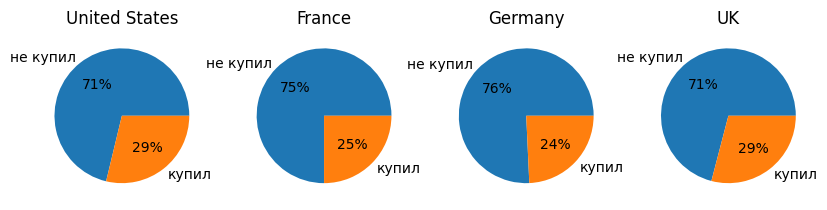

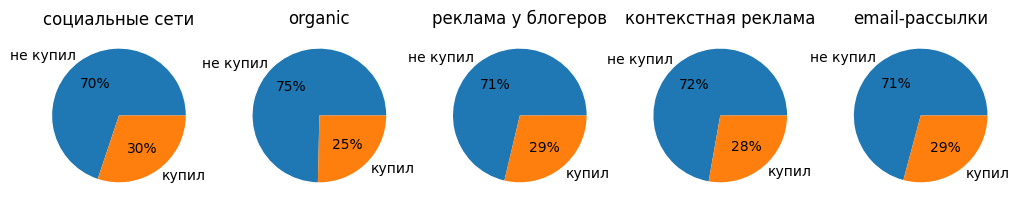

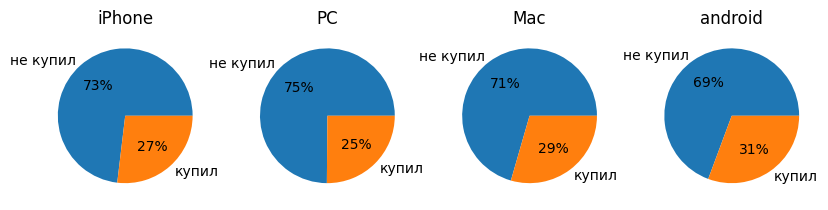

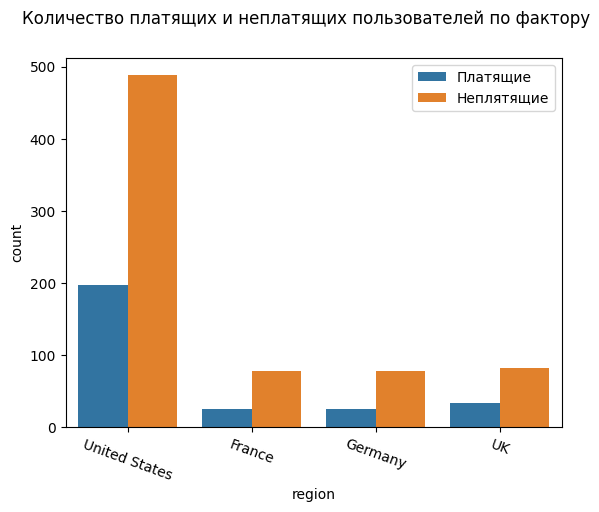

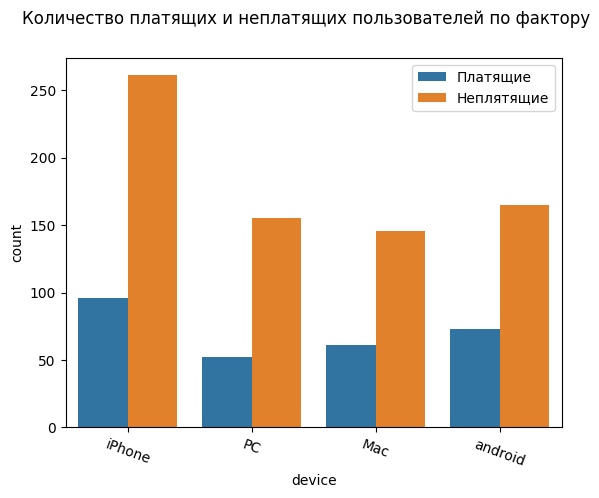

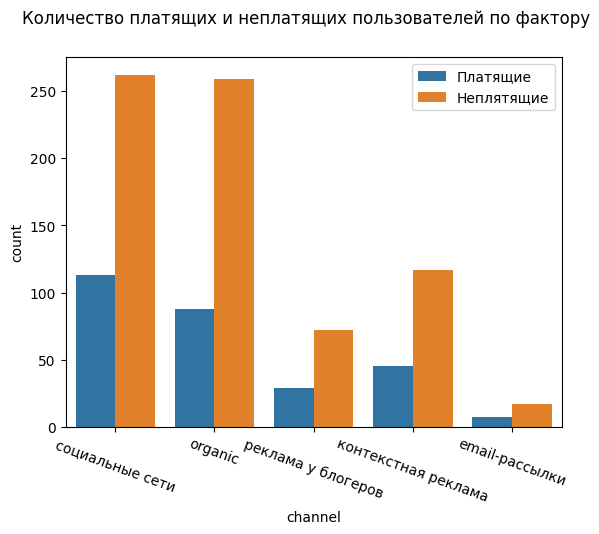

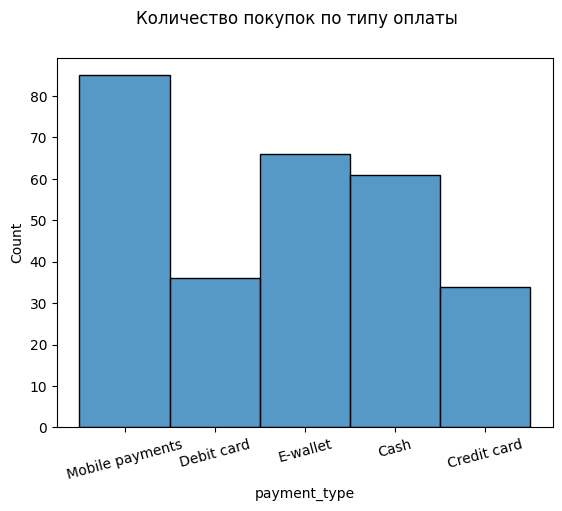

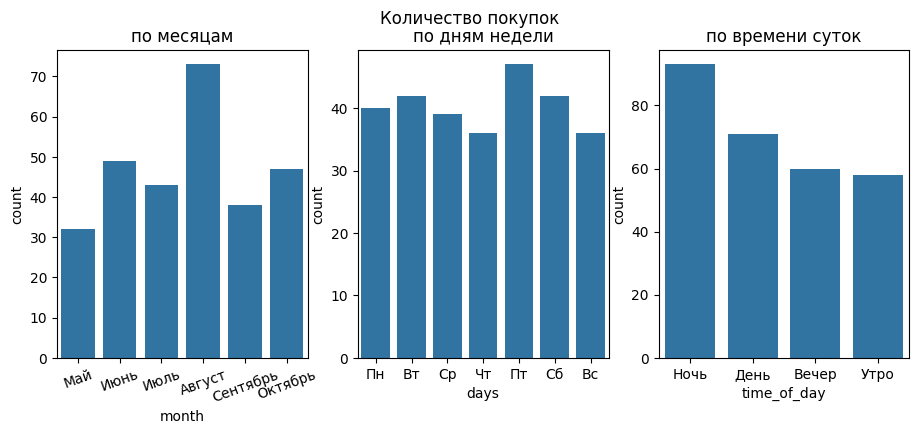

In [15]:
diagrams = DiagramCreator(df)
diagrams.pie_of_payers_by_column(column="region")
diagrams.pie_of_payers_by_column(column="channel")
diagrams.pie_of_payers_by_column(column="device")
diagrams.hist_of_column_by_payer(column="region")
diagrams.hist_of_column_by_payer(column="device")
diagrams.hist_of_column_by_payer(column="channel")
diagrams.hist_of_payers_count_by_column(column="payment_type", russian_name="типу оплаты")
diagrams.hist_of_payers_by_time()

<h4>Инициализация функций для проверки гипотез</h4>

In [16]:
def count_chi2_p(br: pd.DataFrame, gd: pd.DataFrame, rnd: int = -1) -> float:
    crosstab = pd.crosstab(br, gd)
    if rnd >= 0:
        return float(round(chi2_contingency(crosstab).pvalue, rnd))
    return float(chi2_contingency(crosstab).pvalue)


def all_var(df: pd.DataFrame, group: str, value: str):
    mean = df[value].mean()
    mean_group = df.groupby(group)[value].mean()
    size_group = df.groupby(group)[value].size()
    return sum(size_group * (mean_group - mean) ** 2)


def group_var(df: pd.DataFrame, group: str, value: str):
    mean_group = df.groupby(group)[value].mean()
    df["var"] = (df[value] - df[group].map(mean_group)) ** 2
    return df["var"].sum()


def calc_eta(df: pd.DataFrame, group: str, value: str):
    group_disp = group_var(df, group, value)
    all_disp = all_var(df, group, value)
    print(f"group: {group_disp}\nall_disp: {all_disp}")
    return round((all_disp / (group_disp + all_disp)) ** 0.5, 4)


def cramers_stat(df: pd.DataFrame, groups: tuple[str, str], round_zn=0):
    matrix = pd.crosstab(df[groups[0]], df[groups[1]]).to_numpy()
    n = matrix.sum()
    chi2 = chi2_contingency(matrix).statistic
    return round((chi2 / (n * (min(matrix.shape) - 1))) ** 0.5, round_zn)


def cheddock_scale(coef: float) -> str:
    result = ""
    if coef > 0.9:
        result = "Корреляция шкал очень высокая"
    elif coef > 0.7:
        result = "Корреляция шкал высокая"
    elif coef > 0.5:
        result = "Корреляция шкал средняя"
    elif coef > 0.3:
        result = "Корреляция шкал слабая"
    elif coef > 0.1:
        result = "Корреляция шкал очень cлабая"
    else:
        result = "Корреляции между шкалами нет"
    return result


def check_normal(values: pd.Series, alp: float) -> bool:
    return shapiro(values).pvalue > alp


def kruskal_test_region(data: pd.DataFrame, h0: str, h1: str, column: str) -> None:
    print(f"Проверка гипотезы: '{h0}'\nс альтернативной гипозетой: '{h1}'")
    grouped_data = data.groupby(["region", column, "session_date"]).agg(
        purchases=("revenue", lambda x: (x > 0).sum())
    ).reset_index()
    print('\u2500' * 10)
    for region in grouped_data["region"].unique():
        region_data = grouped_data[grouped_data["region"] == region]
        print(f"Регион: {region}")

        p_value = quantitative_and_categorical(region_data, column, "purchases")
        print(f"Тест Краскела-Уоллиса: p-value = {p_value}")
        if p_value < 0.05:
            print(f"Для региона {region} принимаем альтернативную гипотезу")
            print("Проведем попарные сравнения")
            p_c_df = pairwise_comparisons(region_data, column, "purchases")
            result = p_c_df.loc[p_c_df["p-value"] < 0.05]
            print("Записи с p-value < 0.05")
            print(result)
            for i, record in result.iterrows():
                print(f"Среднее количество покупок в день по {record["1 тип"]}: "
                      f"{round(region_data[region_data["channel"] == record["1 тип"]]["purchases"].mean(), 2)}")
                print(f"Среднее количество покупок в день по {record["2 тип"]}: "
                      f"{round(region_data[region_data["channel"] == record["2 тип"]]["purchases"].mean(), 2)}")
        else:
            print(f"Для региона {region} альтернативную гипотезу принимать нельзя")

        print('\u2500' * 10)
    print()


def check_avg_revenue_hypotheses(data: pd.DataFrame, h0: str, h1: str, column: str) -> None:
    print(f"Проверка гипотезы: '{h0}'\nс альтернативной гипозетой: '{h1}'")
    print('\u2500' * 10)

    p_value = quantitative_and_categorical(data, column, "revenue")
    print(f"Тест Краскела-Уоллиса: p-value = {p_value}")
    if p_value < 0.05:
        print(f"Принимаем альтернативную гипотезу: {h1}")
    else:
        print(f"Нельзя отвергнуть нулевую гипотезу: {h0}")
    print('\u2500' * 10)
    print()


def duration_of_the_purchase(data: pd.DataFrame, h0: str, h1: str, column: str) -> None:
    print(f"Проверка гипотезы: '{h0}'\nс альтернативной гипозетой: '{h1}'")
    print('\u2500' * 10)

    buyers = data[data[column] == "yes"]["sessiondurationsec"]
    not_buyers = data[data[column] == "no"]["sessiondurationsec"]

    p_value = quantitative_and_categorical_2(buyers, not_buyers, 4)
    print(f"U-криитерий Манна-Уитни: p-value = {p_value}")

    if p_value < 0.05:
        print(f"Принимаем альтернативную гипотезу: {h1}")
    else:
        print(f"Нельзя отвергнуть нулевую гипотезу: {h0}")
    print('\u2500' * 10)
    print()


def duration_depends_on_the_payment_type(data: pd.DataFrame, h0: str, h1: str, column: str) -> None:
    print(f"Проверка гипотезы: '{h0}'\nс альтернативной гипозетой: '{h1}'")
    print('\u2500' * 10)

    p_value = quantitative_and_categorical(data[data["payer"] == "yes"], column, "sessiondurationsec", 4)
    print(f"Тест Краскела-Уоллиса: p-value = {p_value}")
    if p_value < 0.05:
        print(f"Принимаем альтернативную гипотезу: {h1}")
    else:
        print(f"Нельзя отвергнуть нулевую гипотезу: {h0}")
    print('\u2500' * 10)
    print()


def kruskal_test(columns: list[pd.Series], rnd: int = 4) -> float:
    p = kruskal(*columns).pvalue
    return round(float(p), rnd)


def anova_test(columns: list[pd.Series], rnd: int = 4) -> float:
    p = f_oneway(*columns).pvalue
    return round(float(p), rnd)


def quantitative_and_categorical(data: pd.DataFrame, category: str, quantitative: str, rnd: int = 4):
    if len(data[category].unique()) > 2:
        print("Уровней больше 2-х, значит выбираем между ANOVA и Краскела-Уоллиса")
        return quantitative_and_categorical_3(data, category, quantitative, rnd)
    else:
        print("Всего 2 уровня, значит выбираем между Т-критерием Стьюдента и U-критерием Манны-Уитни")
        columns = data[category].unique()
        br = data[data[category] == columns[0]][quantitative]
        gd = data[data[category] == columns[1]][quantitative]
        return quantitative_and_categorical_2(br, gd, rnd)


def quantitative_and_categorical_2(br: pd.DataFrame, gd: pd.DataFrame, rnd: int = 4):
    if check_normal(br, 0.05) and check_normal(gd, 0.05):
        print("Распределение нормальное, поэтому выбираем Т-критерий Стьюдента")
        return float(round(ttest_ind(br, gd, alternative="two-sided").pvalue, rnd))
    else:
        print("Распределение ненормальное, поэтому выбираем U-крпитерий Манны-Уитни")
        return float(round(mannwhitneyu(br, gd, alternative="two-sided").pvalue, rnd))


def quantitative_and_categorical_3(data: pd.DataFrame, category: str, quantitative: str, rnd: int = 4) -> float:
    unique = data[category].unique()
    columns = [data[data[category] == column][quantitative] for column in unique]
    # print(columns)
    if all([check_normal(column, 0.05) for column in columns]):
        print("Распределение нормальное, поэтому выбираем ANOVA")
        return anova_test(columns, rnd)
    else:
        print("Распределение ненормальное, поэтому выбираем Краскела-Уоллиса")
        return kruskal_test(columns, rnd)


def pairwise_comparisons(data: pd.DataFrame, column: str, quantitative: str) -> pd.DataFrame:
    head = ["p-value", "1 тип", "2 тип"]
    result = []
    for combination in combinations(data[column].unique(), 2):
        br = data[data[column] == combination[0]][quantitative]
        gd = data[data[column] == combination[1]][quantitative]
        result.append([quantitative_and_categorical_2(br, gd), combination[0], combination[1]])
    return pd.DataFrame(result, columns=head)


def count_pearson(br: pd.Series, gd: pd.Series, rnd: int = -1) -> str:
    pears = pearsonr(br, gd)
    if rnd >= 0:
        return f"statistics: {float(round(pears.statistic, rnd))}\npvalue: {float(round(pears.pvalue, rnd))}"
    return f"statistics: {float(pears.statistic)}\npvalue: {float(pears.pvalue)}"


def count_spearman(br: pd.Series, gd: pd.Series, rnd: int = -1) -> str:
    spear = spearmanr(br, gd)
    if rnd >= 0:
        return f"statistics: {float(round(spear.statistic, rnd))}\npvalue: {float(round(spear.pvalue, rnd))}"
    return f"statistics: {float(spear.statistic)}\npvalue: {float(spear.pvalue)}"


def numeric_and_numeric(br: pd.Series, gd: pd.Series, rnd: int = 4) -> str:
    if check_normal(br, 0.05) and check_normal(gd, 0.05):
        print(f"Данные распределены нормально, используем корреляцию Пирсона")
        return count_pearson(br, gd, rnd)
    else:
        print(f"Данные распределены ненормально, используем корреляцию Спирмена")
        return count_spearman(br, gd, rnd)


def numeric_and_numeric_hypo(br: pd.Series, gd: pd.Series, h0: str, h1: str):
    print(f"Проверка гипотезы: '{h0}'\nс альтернативной гипозетой: '{h1}'")
    print("Оба столбца количественные")
    print(numeric_and_numeric(br, gd))

<h4>Выполнение функций для проверки гипотез</h4>

In [17]:
kruskal_test_region(df, "Среднее количество покупок в день одинаково со всеми устройствами",
                    "Среднее количество покупок в день различается в зависимости от типа устройства",
                    'device')
# Различий между средним количеством покупок в день одинаково независимо от типа устройства во всех регионах
kruskal_test_region(df, "Среднее количество покупок в день одинаково в зависимости от типа рекламного канала",
                    "Среднее количество покупок в день различается в зависимости от типа рекламного канала",
                    'channel')
# Между средним количеством покупок в регионе United States есть различия, в зависимости от типа рекламного канала
# После проведения попарных сравнений можно заметить, что среднее количество покупок в день у пользователей, пришедших
# из социальных сетей будет выше, чем у пользователей, пришедших от рекламы блогеров

check_avg_revenue_hypotheses(df, "Cредний чек одинаков в зависимости от региона",
                             "Cредний чек отличается в зависимости от региона",
                             'region')
check_avg_revenue_hypotheses(df, "Cредний чек одинаков в зависимости от рекламного канала",
                             "Cредний чек отличается в зависимости от рекламного канала",
                             'channel')
check_avg_revenue_hypotheses(df, "Cредний чек одинаков в зависимости от времени суток",
                             "Cредний чек отличается в зависимости от времени суток",
                             'time_of_day')
duration_depends_on_the_payment_type(df, "Длительность сессии одинакова у пользователей с разными типами оплаты",
                                     "Длительность сессии различается у пользователей с разными типами оплаты",
                                     "payment_type")

h0 = "Средняя продолжительность сессии одинакова у платящих и неплатящих пользователей"
h1 = "Средняя продолжительность сессии не совпадает у платящих и неплатящих пользователей"
numeric_and_numeric_hypo(df["sessiondurationsec"], df["sum"], h0, h1)
print("коэффициент корреляции ниже 0.3, так что по шкале Чеддока можно сказать, что корреляция отсутствует")
print("т.к. p-value больше 0.05, альтернативную гипотезу принимать нельзя")

Проверка гипотезы: 'Среднее количество покупок в день одинаково со всеми устройствами'
с альтернативной гипозетой: 'Среднее количество покупок в день различается в зависимости от типа устройства'
──────────
Регион: France
Уровней больше 2-х, значит выбираем между ANOVA и Краскела-Уоллиса
Распределение ненормальное, поэтому выбираем Краскела-Уоллиса
Тест Краскела-Уоллиса: p-value = 0.1911
Для региона France альтернативную гипотезу принимать нельзя
──────────
Регион: Germany
Уровней больше 2-х, значит выбираем между ANOVA и Краскела-Уоллиса
Распределение ненормальное, поэтому выбираем Краскела-Уоллиса
Тест Краскела-Уоллиса: p-value = 0.6412
Для региона Germany альтернативную гипотезу принимать нельзя
──────────
Регион: UK
Уровней больше 2-х, значит выбираем между ANOVA и Краскела-Уоллиса
Распределение ненормальное, поэтому выбираем Краскела-Уоллиса
Тест Краскела-Уоллиса: p-value = 0.7585
Для региона UK альтернативную гипотезу принимать нельзя
──────────
Регион: United States
Уровней боль

<h4>Инициализация функций для построения регрессионной модели</h4>

In [29]:
def fit_transform(train: pd.DataFrame, test: pd.DataFrame, _ohe: OneHotEncoder, column: str = "") -> \
        (pd.DataFrame, pd.DataFrame):
    train_new = pd.DataFrame(_ohe.fit_transform(train[[column]]),
                             columns=_ohe.categories_, index=train.index)  # получаем закодированную версию колонки
    train_other_cols = train.drop(columns=column)  # получаем остальные колнки
    train = pd.concat([train_new, train_other_cols], axis=1)  # соединение новых значений и старых

    # аналогично 
    test_new = pd.DataFrame(_ohe.fit_transform(test[[column]]), columns=_ohe.categories_, index=test.index)
    test_other_cols = test.drop(columns=column)
    test = pd.concat([test_new, test_other_cols], axis=1)

    return train, test


def print_metrics_model(fact: pd.DataFrame, predict: np.ndarray) -> None:
    print(f"R2 = {round(r2_score(fact, predict), 4)}")
    print(f"MAPE = {round(mean_absolute_percentage_error(fact, predict) * 100, -18)}")
    print(f"MAE = {round(mean_absolute_error(fact, predict))}")
    print(f"RMSE = {round(mean_squared_error(fact, predict) ** 0.5)}")

<h4>Построение модели и выведение результатов ее точности</h4>
<p>Модель получает на вход датафрейм и колнки, разъединенные на категориальные и количественные, которые используются для построения модели, предсказывающей сумму покупки на их основе</p>

Были выбраны шкалы region, channel, , потому что они должны влиять на суммы продаж

Метрики модели
R2 = -0.0224
MAPE = 4.7e+20
MAE = 2081
RMSE = 2344
──────────
Первые 5 значений предсказания для тестовой выборки:


,region,channel,revenue
0,United States,organic,1264
1,France,email-рассылки,1584
2,United States,organic,1264
3,United States,organic,1264
4,UK,organic,1312


──────────
Максимальные значения дохода для групп в предсказании:


,,max_revenue
region,channel,
United States,organic,1264
UK,organic,1312
United States,реклама у блогеров,1360
UK,реклама у блогеров,1408
France,organic,1424
Germany,organic,1432
UK,email-рассылки,1472
United States,социальные сети,1472
France,реклама у блогеров,1520


──────────


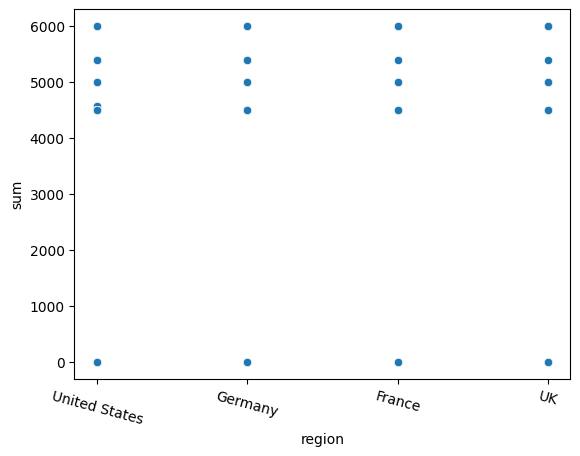

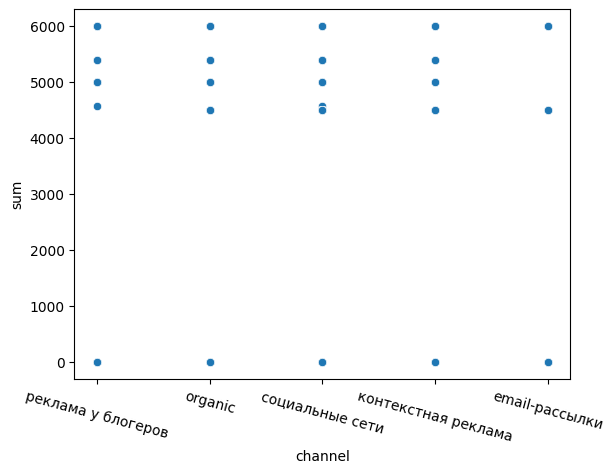

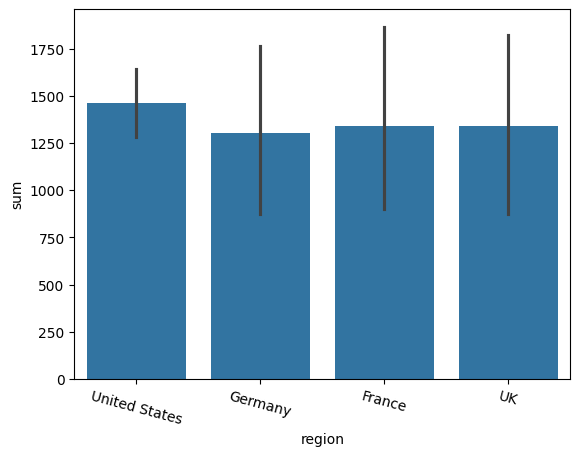

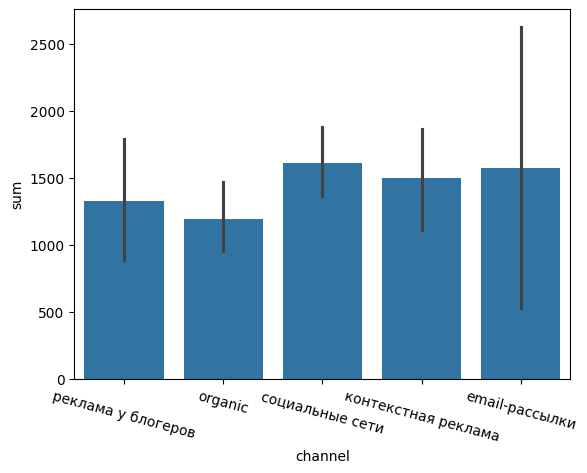

In [30]:
selling_columns_cat = ["region", "channel"]  # категориальные колонки, на основе которые строится модель
selling_columns_num = []  # количественные колонки, на основе которые строится модель
x_train, x_test, y_train, y_test = train_test_split(df[selling_columns_cat + selling_columns_num],
                                                    df["sum"], test_size=0.15, random_state=0)
x_train_orig = x_train.copy()
x_test_orig = x_test.copy()

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
for i in selling_columns_cat:
    x_train, x_test = fit_transform(x_train, x_test, ohe, i)  # кодирование категориальных колонок с помощью OneHotEncoder


lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
prediction = lin_reg.predict(x_test)

print(f"Были выбраны шкалы {", ".join(selling_columns_cat)}, {", ".join(selling_columns_num)}, "
      f"потому что они должны влиять на суммы продаж\n")
print("Метрики модели")
print_metrics_model(y_test, prediction)
print("\u2500" * 10)

prediction = pd.concat([x_test_orig.reset_index(drop=True), pd.DataFrame(prediction)], axis=1)
prediction[0] = prediction[0].astype(int)


print("Первые 5 значений предсказания для тестовой выборки:")
display(prediction.head().rename({0: "revenue"}, axis=1))
print("\u2500" * 10)

print("Максимальные значения дохода для групп в предсказании:")
display(prediction.groupby(selling_columns_cat + selling_columns_num).agg("max").sort_values(0).rename({0: "max_revenue"}, axis=1))
print("\u2500" * 10)


for i in selling_columns_cat + selling_columns_num:  # создание диаграмм рассеивания на основе всех колонок модели
    sns.scatterplot(x=x_train_orig[i], y=y_train)
    plt.xticks(rotation=-15)
    plt.show()

for i in selling_columns_cat:  # создание гистограмм на основе категориальных колонок модели
    sns.barplot(x=x_train_orig[i], y=y_train)
    plt.xticks(rotation=-15)
    plt.show()
for i in selling_columns_num:  # создание гистограмм на основе количественных колонок модели
    sns.histplot(x=x_train_orig[i], y=y_train)
    plt.xticks(rotation=-15)
    plt.show()


<p>Исходя из графиков и значений метрик можно сделать вывод, что построенная модель - некачественная.</p>
<p>Вероятно, это случилось из-за того, что шкалы, которые должны были оказать воздействие, на самом деле не оказали его, что было установлено в ходе проверки гипотез</p>
<p> Также причиной может быть распределение сумм продаж т.к. нет промежуточных значений между минимальной суммой покпки и теми, кто ничего не купил.</p>